### 1. Importing libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

### 2. Reading the dataset

In [2]:
df = pd.read_csv('/kaggle/input/datasets/sachinpatel21/az-handwritten-alphabets-in-csv-format/A_Z Handwritten Data.csv').astype('float32')
df.head(10)

,0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,...,0.639,0.640,0.641,0.642,0.643,0.644,0.645,0.646,0.647,0.648
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [3]:
df.shape

(372450, 785)

### 3. Splitting the dataframe, 'X' contain the feature of the image, whereas 'y' contain the label of the image.

In [4]:
#Dropping of the first column, which is the label of the image
X = df.drop('0', axis = 1)

#And the dropped column is assigned to 'y'
y = df['0']

### 4. Train-test-split on X and y

In [5]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(X, y, test_size = 0.2)

### 5. Reshaping the Training and Testing data, which are in 784 column of pixel data into 28x28 pixels.

In [6]:
x_train = np.reshape(x_train.values, (x_train.shape[0], 28, 28))
x_test = np.reshape(x_test.values, (x_test.shape[0], 28, 28))

print("Shape of Training Data", x_train.shape)
print("Shape of Testing Data", x_test.shape)

Shape of Training Data (297960, 28, 28)
Shape of Testing Data (74490, 28, 28)


### 6. Shuffle the training data

In [7]:
from sklearn.utils import shuffle

shuffle_data = shuffle(x_train)

#Shuffling is done on the training data, because the model should not become biased, if there is linearity in the given sample.

### 7. Visualise the training data

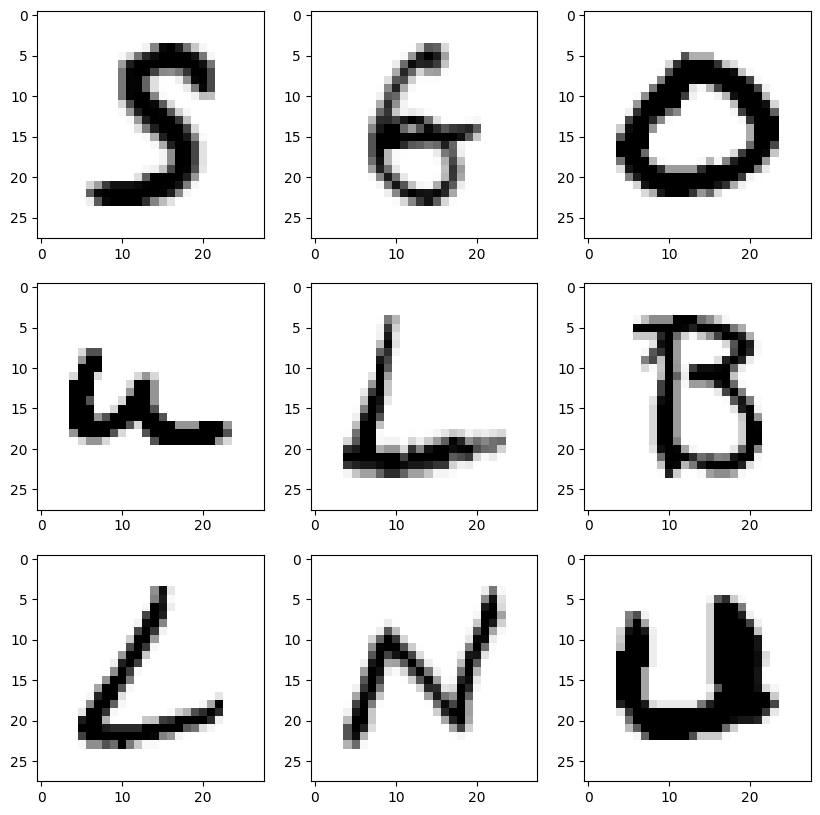

In [8]:
import cv2

fig, axes = plt.subplots(3, 3, figsize = (10, 10))
axes = axes.flatten()

for i in range(9):
    _, shu = cv2.threshold(shuffle_data[i], 30, 200, cv2.THRESH_BINARY)
    
    axes[i].imshow(np.reshape(shuffle_data[i], (28, 28)), cmap = "Greys")

plt.show()

In [9]:
print("Training data shape", x_train.shape)
print("Testing data shape", x_test.shape)

Training data shape (297960, 28, 28)
Testing data shape (74490, 28, 28)


### 8. Reshaping the obtained image data

In [10]:
x_train = x_train.reshape(x_train.shape[0], x_train.shape[1], x_train.shape[2], 1)
x_test = x_test.reshape(x_test.shape[0], x_test.shape[1], x_test.shape[2], 1)

print("New shape of the Training Data", x_train.shape)
print("New shape of the Test Data", x_test.shape)

New shape of the Training Data (297960, 28, 28, 1)
New shape of the Test Data (74490, 28, 28, 1)


We have done this reshaping to add the number of channels value in the shape of the dataframe (whether in training or test data). Here we considering and doing only on the Grey color, so the number of channels = 1 

### 9. Converting to_categorical

to_categorical is used to convert the labels into the manner where the model easily understands it, i.e one-hot-encoder.

if a = [1, 2, 3]
model predicts as 3>2>1 of importance, which is of false.

So we make one-hot-encoding, where the its original position is only 1, rest are 0, i.e, 
[[1, 0, 0], [0, 1, 0], [0, 0, 1]]

In [11]:
import tensorflow
from tensorflow.keras.utils import to_categorical

y_training = to_categorical(y_train, num_classes = 26)
y_testing = to_categorical(y_test, num_classes = 26)

2026-05-06 11:13:48.284515: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778066028.553273      16 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778066028.633529      16 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778066029.340862      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778066029.340897      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778066029.340902      16 computation_placer.cc:177] computation placer alr

Here, the num_classes are the number of columns of the one-hot-encoder matrix. It is important to intialise to obtain the desired number of columns when they are in output layers. Or else it takes in general (max(label)+1).

### 10. Model Creation

In [12]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Conv2D, MaxPool2D, Dropout

from tensorflow.keras.optimizers import SGD, Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping

Hidden Layers
* 3 Convolution Layers of 64 layers each, followed by MaxPool
* And after flatten the layers, 2 fully connected layers (Dense layers) of 128, 256 respectively
* And at last output layer is FC layer with softmax as an activation function

In [13]:
model = Sequential()

#Layer 1
model.add(Conv2D(64, (3, 3), activation = 'relu', input_shape = (28, 28, 1)))
model.add(MaxPool2D(2, 2))

#Layer 2
model.add(Conv2D(64, (3 ,3), activation = 'relu'))
model.add(MaxPool2D(2, 2))

#Layer 3
model.add(Conv2D(64, (3 ,3), activation = 'relu'))
model.add(MaxPool2D(2, 2))

#Flatten the 2D matrix
model.add(Flatten())

# FC Layer
model.add(Dense(128, activation = 'relu'))
model.add(Dense(256, activation = 'relu'))

#Output Layer
model.add(Dense(26, activation = 'softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-05-06 11:14:19.393307: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


### 11. Model Summary

In [14]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 3, 3, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 1, 1, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 26)             │         6,682 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 122,522 (478.60 KB)

 Trainable params: 122,522 (478.60 KB)

 Non-trainable params: 0 (0.00 B)

### 12. Compile and Fit the model

In [15]:
model.compile(
    optimizer = Adam(learning_rate = 0.001), 
    loss = 'categorical_crossentropy', 
    metrics = ['accuracy'])

history = model.fit(x_train, y_training, 
                    epochs = 5, 
                    validation_data = (x_test, y_testing))

Epoch 1/5
9312/9312 ━━━━━━━━━━━━━━━━━━━━ 259s 28ms/step - accuracy: 0.8864 - loss: 0.4206 - val_accuracy: 0.9637 - val_loss: 0.1255
Epoch 2/5
9312/9312 ━━━━━━━━━━━━━━━━━━━━ 254s 27ms/step - accuracy: 0.9660 - loss: 0.1195 - val_accuracy: 0.9699 - val_loss: 0.1134
Epoch 3/5
9312/9312 ━━━━━━━━━━━━━━━━━━━━ 255s 27ms/step - accuracy: 0.9726 - loss: 0.0983 - val_accuracy: 0.9737 - val_loss: 0.0960
Epoch 4/5
9312/9312 ━━━━━━━━━━━━━━━━━━━━ 260s 28ms/step - accuracy: 0.9752 - loss: 0.0898 - val_accuracy: 0.9723 - val_loss: 0.1013
Epoch 5/5
9312/9312 ━━━━━━━━━━━━━━━━━━━━ 256s 27ms/step - accuracy: 0.9767 - loss: 0.0866 - val_accuracy: 0.9721 - val_loss: 0.1191


In [16]:
model.compile(
    optimizer = Adam(learning_rate = 0.001), 
    loss = 'categorical_crossentropy', 
    metrics = ['accuracy'])

print(model.optimizer)

### 13. Save the model

In [17]:
model.save('handwritten_character_recog_model.keras')

### 14. Creating words Dictinory

In [18]:
words = {0:'A',1:'B',2:'C',3:'D',4:'E',5:'F',6:'G',7:'H',8:'I',9:'J',10:'K',11:'L',12:'M',13:'N',14:'O',15:'P',16:'Q',17:'R',18:'S',19:'T',20:'U',21:'V',22:'W',23:'X', 24:'Y',25:'Z'}

### 15. Prediction Process

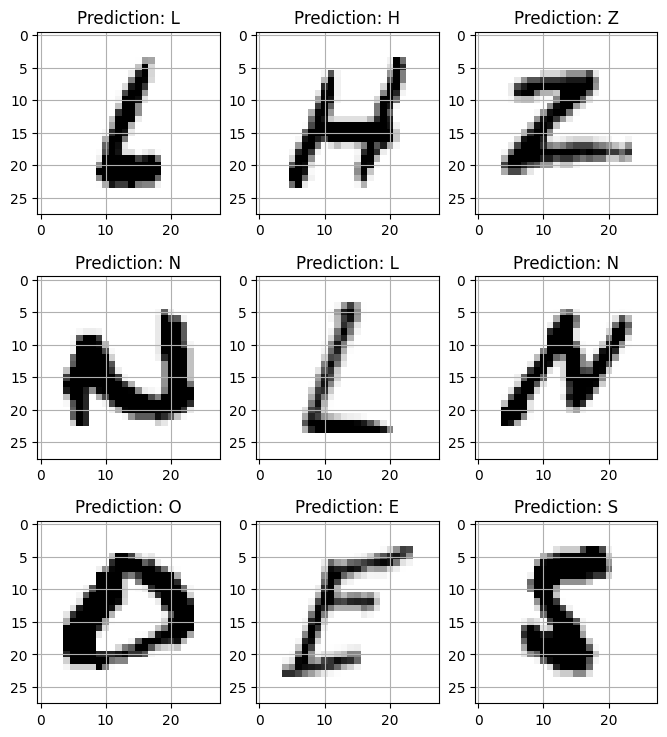

In [19]:
fig, axes = plt.subplots(3, 3, figsize=(8, 9))
axes = axes.flatten()

for i, ax in enumerate(axes):
    image = np.reshape(x_test[i], (28, 28))
    ax.imshow(image, cmap = 'Greys')
    pred = words[np.argmax(y_testing[i])]
    ax.set_title("Prediction: " +pred)
    ax.grid()

### 16. Visulaize the model with Custom image

In [20]:
import cv2
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np

In [21]:
from keras.models import load_model
model = load_model('handwritten_character_recog_model.keras')

model.compile(
    optimizer = Adam(learning_rate = 0.001), 
    loss = 'categorical_crossentropy', 
    metrics = ['accuracy'])

print(model.optimizer)

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 26 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Note:
* Optimizers does not have any affect on prediction of charater/ any prediction.
* And, here model.complie() is used again to use Adam optimizer, which is used in training also.

In [22]:
words = {0:'A',1:'B',2:'C',3:'D',4:'E',5:'F',6:'G',7:'H',8:'I',9:'J',10:'K',11:'L',12:'M',13:'N',14:'O',15:'P',16:'Q',17:'R',18:'S',19:'T',20:'U',21:'V',22:'W',23:'X', 24:'Y',25:'Z'}

Reading the image from '/dataset/images'

In [23]:
image = cv2.imread("/kaggle/input/datasets/shamanthsr/q-image/q-image.jpg" )
image_copy = image.copy()

#We are converting obtained image color BGR to standard RGB
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB) 
image = cv2.resize(image, (400, 440))

image_copy = cv2.GaussianBlur(image_copy, (7,7), 0)
gray_image = cv2.cvtColor(image_copy, cv2.COLOR_BGR2GRAY)
_, img_thresh = cv2.threshold(gray_image, 100, 255, cv2.THRESH_BINARY_INV)

final_image = cv2.resize(img_thresh, (28, 28))
final_image = np.reshape(final_image, (1, 28, 28, 1))

prediction = words[np.argmax(model.predict(final_image))]

print(prediction)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step
R


## That's the wrap up of the learning from this project.